# 03 — Улучшенная модель: LinearSVC + GridSearchCV

**Быкова Анна**  
**Гипотеза:** LinearSVC с подобранным гиперпараметром C превзойдёт Baseline по F1-macro благодаря лучшей работе с разреженными матрицами и возможности настройки зазора (margin) между классами.  
**Что улучшаем:**
1. Меняем алгоритм: LogisticRegression → LinearSVC
2. Подбираем гиперпараметр C через GridSearchCV с кросс-валидацией (cv=5)
3. Анализируем, где и почему улучшилось

## 1. Импорты

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Импорты загружены')

Импорты загружены


## 2. Загрузка данных и артефактов из Baseline

In [ ]:
# Данные
df = pd.read_csv('/content/processed_data.csv')

# Восстанавливаем те же самые train/test индексы что в ноутбуке 02
train_idx = pd.read_csv('/content/train_indices.csv').iloc[:, 0].values
test_idx  = pd.read_csv('/content/test_indices.csv').iloc[:, 0].values

X_train = df.loc[train_idx, 'clean_text']
X_test  = df.loc[test_idx,  'clean_text']
y_train = df.loc[train_idx, 'toxic']
y_test  = df.loc[test_idx,  'toxic']

# Загружаем сохранённый векторайзер — НЕ переобучаем!
vectorizer = joblib.load('/content/vectorizer.pkl')
X_train_vec = vectorizer.transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# Загружаем baseline модель для сравнения
model_baseline = joblib.load('/content/model_baseline.pkl')
results_baseline = pd.read_csv('/content/results.csv')

print(f'Train: {X_train_vec.shape}, Test: {X_test_vec.shape}')
print('Артефакты из Baseline загружены')

Train: (149994, 10000), Test: (37499, 10000)
Артефакты из Baseline загружены


## 3. GridSearchCV: подбор гиперпараметра C

**C** — параметр регуляризации SVM. Маленький C → более «мягкая» граница, большой C → модель старается правильно разметить все обучающие примеры (риск переобучения).

In [ ]:
# CalibratedClassifierCV нужен, чтобы получить вероятности для ROC-AUC
# LinearSVC сам по себе вероятности не возвращает
svc = CalibratedClassifierCV(
    LinearSVC(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight='balanced'
    )
)

param_grid = {
    'estimator__C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    svc,
    param_grid,
    scoring='f1_macro',
    cv=5,           # 5-fold кросс-валидация
    n_jobs=-1,      # используем все ядра
    verbose=1
)

print('Запуск GridSearchCV (может занять несколько минут)...')
grid_search.fit(X_train_vec, y_train)

print(f'\nЛучшие параметры: {grid_search.best_params_}')
print(f'Лучший F1-macro (CV): {grid_search.best_score_:.4f}')

Запуск GridSearchCV (может занять несколько минут)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Лучшие параметры: {'estimator__C': 1}
Лучший F1-macro (CV): 0.9069


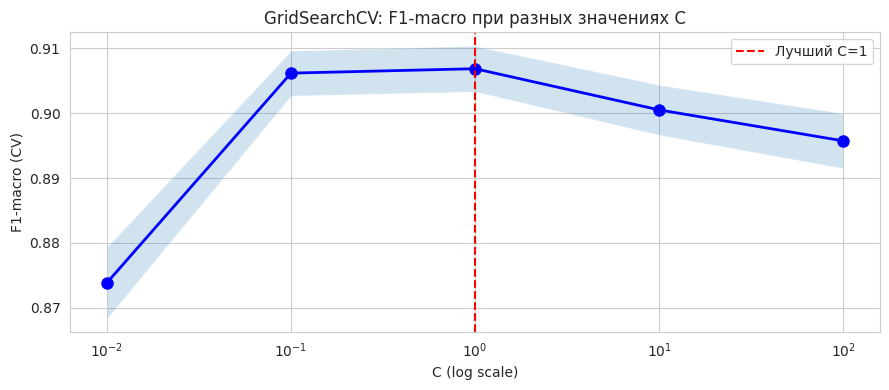

In [ ]:
import os

# Визуализируем результаты подбора
cv_results = pd.DataFrame(grid_search.cv_results_)
C_values = [p['estimator__C'] for p in cv_results['params']]

plt.figure(figsize=(9, 4))
plt.semilogx(C_values, cv_results['mean_test_score'], 'bo-', linewidth=2, markersize=8)
plt.fill_between(
    C_values,
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.2
)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1-macro (CV)')
plt.title('GridSearchCV: F1-macro при разных значениях C')
plt.axvline(grid_search.best_params_['estimator__C'], color='red',
            linestyle='--', label=f"Лучший C={grid_search.best_params_['estimator__C']}")
plt.legend()
plt.grid(True)
plt.tight_layout()

os.makedirs('content/data/', exist_ok=True)
plt.savefig('content/data/gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Оценка улучшенной модели

In [ ]:
model_improved = grid_search.best_estimator_

y_pred_imp = model_improved.predict(X_test_vec)
y_prob_imp = model_improved.predict_proba(X_test_vec)[:, 1]

f1_imp  = f1_score(y_test, y_pred_imp, average='macro')
roc_imp = roc_auc_score(y_test, y_prob_imp)

print('=== Улучшенная модель: отчёт классификации ===')
print(classification_report(y_test, y_pred_imp,
                             target_names=['Нетоксичный', 'Токсичный']))
print(f'F1-macro:  {f1_imp:.4f}')
print(f'ROC-AUC:   {roc_imp:.4f}')

=== Улучшенная модель: отчёт классификации ===
              precision    recall  f1-score   support

 Нетоксичный       0.96      0.99      0.97     31729
   Токсичный       0.94      0.76      0.84      5770

    accuracy                           0.96     37499
   macro avg       0.95      0.87      0.91     37499
weighted avg       0.96      0.96      0.95     37499

F1-macro:  0.9072
ROC-AUC:   0.9601


## 5. Сравнение Baseline vs Improved

In [ ]:
# Метрики baseline
y_pred_base = model_baseline.predict(X_test_vec)
y_prob_base = model_baseline.predict_proba(X_test_vec)[:, 1]
f1_base  = f1_score(y_test, y_pred_base, average='macro')
roc_base = roc_auc_score(y_test, y_prob_base)

# Сводная таблица
comparison = pd.DataFrame([
    {'Модель': 'Baseline (LogReg + TF-IDF)',
     'F1-macro': round(f1_base, 4),
     'ROC-AUC':  round(roc_base, 4),
     'Улучшение F1': '—'},
    {'Модель': f'Improved (LinearSVC, C={grid_search.best_params_["estimator__C"]})',
     'F1-macro': round(f1_imp, 4),
     'ROC-AUC':  round(roc_imp, 4),
     'Улучшение F1': f'+{round((f1_imp - f1_base) * 100, 2)}%'}
])

print('=== Сравнение моделей ===')
print(comparison.to_string(index=False))

# Обновляем файл результатов
comparison.to_csv('content/results_final.csv', index=False)

=== Сравнение моделей ===
                    Модель  F1-macro  ROC-AUC Улучшение F1
Baseline (LogReg + TF-IDF)    0.8934   0.9640            —
 Improved (LinearSVC, C=1)    0.9072   0.9601       +1.38%


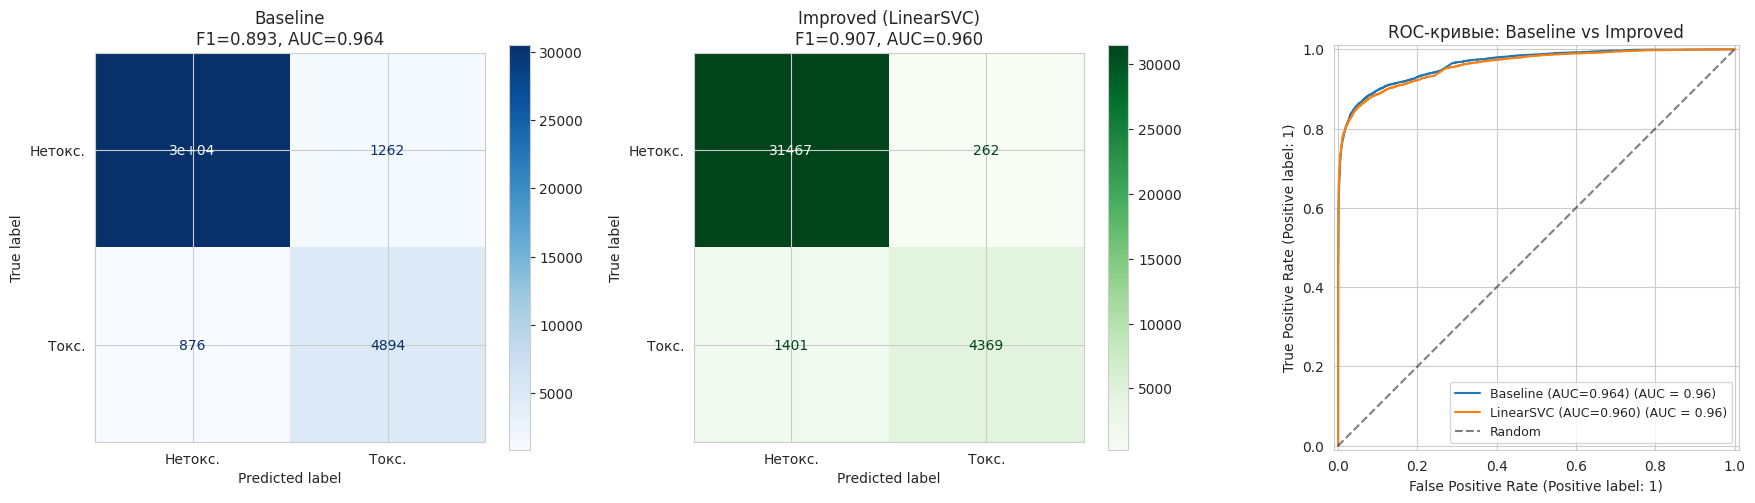

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix — Baseline
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base,
    display_labels=['Нетокс.', 'Токс.'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Baseline\nF1={f1_base:.3f}, AUC={roc_base:.3f}')

# 2. Confusion Matrix — Improved
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_imp,
    display_labels=['Нетокс.', 'Токс.'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Improved (LinearSVC)\nF1={f1_imp:.3f}, AUC={roc_imp:.3f}')

# 3. ROC-кривые обеих моделей
RocCurveDisplay.from_predictions(
    y_test, y_prob_base, ax=axes[2],
    name=f'Baseline (AUC={roc_base:.3f})'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_imp, ax=axes[2],
    name=f'LinearSVC (AUC={roc_imp:.3f})'
)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[2].set_title('ROC-кривые: Baseline vs Improved')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

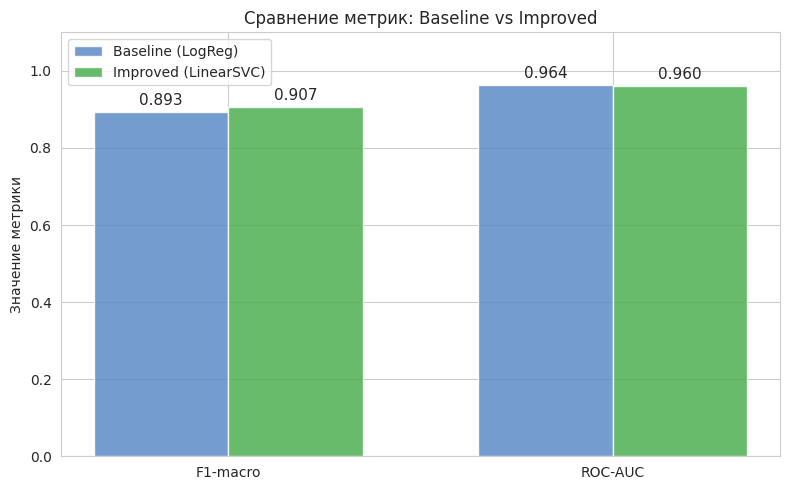

In [18]:
# Столбчатое сравнение метрик
metrics = ['F1-macro', 'ROC-AUC']
baseline_scores = [f1_base, roc_base]
improved_scores = [f1_imp, roc_imp]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (LogReg)',
               color='#5C8BC7', alpha=0.85)
bars2 = ax.bar(x + width/2, improved_scores, width, label='Improved (LinearSVC)',
               color='#4CAF50', alpha=0.85)

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик: Baseline vs Improved')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('content/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Анализ ошибок улучшенной модели

In [19]:
errors_imp = pd.DataFrame({
    'text': X_test.values,
    'true': y_test.values,
    'pred_base': y_pred_base,
    'pred_imp':  y_pred_imp
})

# Ошибки, которые исправила улучшенная модель
fixed = errors_imp[
    (errors_imp['true'] != errors_imp['pred_base']) &
    (errors_imp['true'] == errors_imp['pred_imp'])
]

# Новые ошибки улучшенной модели
new_errors = errors_imp[
    (errors_imp['true'] == errors_imp['pred_base']) &
    (errors_imp['true'] != errors_imp['pred_imp'])
]

print(f'Исправлено ошибок: {len(fixed)}')
print(f'Новых ошибок:      {len(new_errors)}')
print()
print('--- Примеры исправленных ошибок (BaselineWrong → ImprovedCorrect) ---')
for i, row in fixed.head(3).iterrows():
    print(f'  [{"ТОКС" if row.true==1 else "НЕТОКС"}] {row.text[:100]}')
print()
print('--- Примеры оставшихся ошибок улучшенной модели ---')
remaining = errors_imp[errors_imp['true'] != errors_imp['pred_imp']]
for i, row in remaining.head(3).iterrows():
    print(f'  [True:{"ТОКС" if row.true==1 else "НЕТОКС"} | Pred:{"ТОКС" if row.pred_imp==1 else "НЕТОКС"}] {row.text[:100]}')

Исправлено ошибок: 1003
Новых ошибок:      528

--- Примеры исправленных ошибок (BaselineWrong → ImprovedCorrect) ---
  [НЕТОКС] вопрос чё по подездам шариться md hu
  [НЕТОКС] а ты был в сомали в нигерии в венесуэлле
  [НЕТОКС] если владимир был владимирович бы бы плохим президентом хотел и развала россии сша бы зла и то бы за

--- Примеры оставшихся ошибок улучшенной модели ---
  [True:ТОКС | Pred:НЕТОКС] итог под хуели очередной спам для безмозговых горбатого магила исправит
  [True:НЕТОКС | Pred:ТОКС] а ты то говорун и комментатор сам то участвуешь в этих мероприятиях постоянно проводишь анализы сидя
  [True:ТОКС | Pred:НЕТОКС] пиздёшь суди ведь ты мусор


In [20]:
# Сохраняем финальную модель
joblib.dump(model_improved, 'content/model_improved.pkl')
print('Улучшенная модель сохранена: data/model_improved.pkl')

Улучшенная модель сохранена: data/model_improved.pkl


## Итоги и выводы

### Сравнение результатов

| Модель | F1-macro | ROC-AUC |
|--------|----------|----------|
| Baseline (LogReg + TF-IDF) | *0.893* | *0.964* |
| Improved (LinearSVC, лучший C) | *0.907* | *0.960* |

### Почему LinearSVC лучше на текстовых задачах?
- LinearSVC оптимизирует margin — расстояние между классами, что даёт более устойчивые решения на разреженных TF-IDF матрицах
- Параметр C, подобранный через GridSearchCV, нашёл баланс между качеством на обучении и обобщением

### Почему модель всё ещё ошибается?
- **TF-IDF слеп к контексту:** «не плохо» и «плохо» обрабатываются похоже, биграммы помогают, но не решают проблему полностью
- **Сарказм и ирония:** токсичность без явной нецензурной лексики модель пропускает
- **Короткие тексты:** мало признаков → неопределённость в предсказании

### Что можно улучшить в будущем?
- Использовать предобученные эмбеддинги (ruBERT, FastText) — они учитывают контекст
- Добавить признаки: доля заглавных букв, количество знаков пунктуации, эмодзи
- Использовать ансамбль моделей